Searching for dataset folders...
SUCCESS! Found Images at: /kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images
SUCCESS! Found Masks at: /kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/1st_manual

--- RESULTS ---
Average Sensitivity (Niblack Method): 0.7854
Average Sensitivity (Sauvola Method): 0.5859


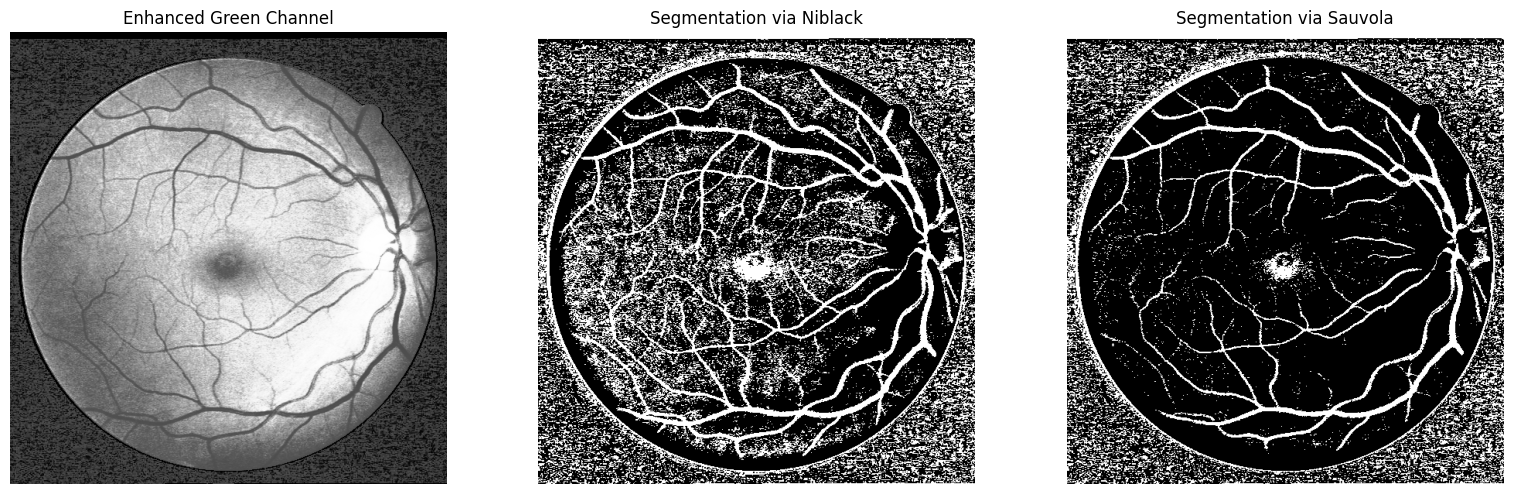

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola

#  AUTO-DISCOVER FILE PATHS
print("Searching for dataset folders...")
path_to_train_imgs = None
path_to_ground_truth = None

for root, dirs, files in os.walk('/kaggle/input'):
    if root.endswith('training/images'):
        path_to_train_imgs = root
    elif root.endswith('training/1st_manual'):
        path_to_ground_truth = root

if not path_to_train_imgs or not path_to_ground_truth:
    print("ERROR: Could not automatically find the 'images' or '1st_manual' folders.")
    print("Please ensure the DRIVE dataset is fully added to this Kaggle notebook.")
else:
    print(f"SUCCESS! Found Images at: {path_to_train_imgs}")
    print(f"SUCCESS! Found Masks at: {path_to_ground_truth}")

    # 2. Helper Functions 
    def enhance_retinal_contrast(color_image):
        """Extracts the green channel and equalizes the histogram."""
        green_channel = color_image[:, :, 1]
        enhanced_image = cv2.equalizeHist(green_channel)
        return enhanced_image

    def extract_vessels_local_thresh(enhanced_image, filter_window=41):
        """Applies local thresholding (Niblack and Sauvola) to isolate dark vessels."""
        niblack_limit = threshold_niblack(enhanced_image, window_size=filter_window, k=0.2)
        mask_niblack = (enhanced_image < niblack_limit).astype(np.uint8)

        sauvola_limit = threshold_sauvola(enhanced_image, window_size=filter_window)
        mask_sauvola = (enhanced_image < sauvola_limit).astype(np.uint8)

        return mask_niblack, mask_sauvola

    def calculate_tpr(predicted_mask, true_mask):
        """Calculates True Positive Rate (Sensitivity / Recall)."""
        true_mask_bin = (true_mask > 0).astype(np.uint8)
        true_positives = np.sum((predicted_mask == 1) & (true_mask_bin == 1))
        false_negatives = np.sum((predicted_mask == 0) & (true_mask_bin == 1))
        tpr = true_positives / (true_positives + false_negatives + 1e-8)
        return tpr

    # 3. Main Processing Loop
    image_files = sorted(os.listdir(path_to_train_imgs))
    mask_files = sorted(os.listdir(path_to_ground_truth))

    niblack_sensitivities = []
    sauvola_sensitivities = []

    for img_filename, mask_filename in zip(image_files, mask_files):
        
        raw_img = cv2.imread(os.path.join(path_to_train_imgs, img_filename))
        actual_mask = cv2.imread(os.path.join(path_to_ground_truth, mask_filename), 0)

        processed_img = enhance_retinal_contrast(raw_img)
        niblack_pred, sauvola_pred = extract_vessels_local_thresh(processed_img)

        niblack_sensitivities.append(calculate_tpr(niblack_pred, actual_mask))
        sauvola_sensitivities.append(calculate_tpr(sauvola_pred, actual_mask))

    # 4. Print Results 
    print("\n--- RESULTS ---")
    print(f"Average Sensitivity (Niblack Method): {np.mean(niblack_sensitivities):.4f}")
    print(f"Average Sensitivity (Sauvola Method): {np.mean(sauvola_sensitivities):.4f}")

    # 5. Visual Comparison
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].imshow(processed_img, cmap='gray')
    axes[0].set_title("Enhanced Green Channel")
    axes[0].axis('off')

    axes[1].imshow(niblack_pred, cmap='gray')
    axes[1].set_title("Segmentation via Niblack")
    axes[1].axis('off')

    axes[2].imshow(sauvola_pred, cmap='gray')
    axes[2].set_title("Segmentation via Sauvola")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()